# To plot results related to Obj 3

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob, os

def get_broadcast_results_uav_int(path,filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    """
    results = []
    scenarios = glob.glob(path + "/*")
    for scenario in scenarios:
        interference_distance = scenario.split("InterferenceDistance-")[-1].split("_")[0]
        uav_gcs_int_distance = scenario.split("UAVGCSInterfererDist-")[-1].split("_")[0]
        results_df = pd.read_csv(os.path.join(scenario, filename))
        avg_dl_rel = results_df["Total_Reliability_DL"].mean()
        avg_ul_rel = results_df["Total_Reliability_UL"].mean()
        if "Useful_Packet_Reception_Ratio_DL" in results_df.columns:
            avg_uprr = results_df["Useful_Packet_Reception_Ratio_DL"].mean()
        else:
            avg_uprr = np.nan
        results.append({"distance_a": float(interference_distance), "distance_b": float(uav_gcs_int_distance),
                        "avg_dl_rel": avg_dl_rel, "avg_ul_rel": avg_ul_rel, "avg_uprr": avg_uprr})
    return pd.DataFrame(results).sort_values(by=['distance_a', 'distance_b'], ascending=[True, True])

def get_broadcast_results_manet_int(path, filename="Broadcast_Metrics.csv"):
    """
    Given the root path for results, get the results for each scenario in a DF
    filename is the CSV file name to look for under each scenario folder
    """
    results = []
    scenarios = glob.glob(path + "/*")
    for scenario in scenarios:
        num_node = scenario.split("MANETNumNode-")[-1].split("_")[0]
        results_df = pd.read_csv(os.path.join(scenario, filename))
        avg_dl_rel = results_df["Total_Reliability_DL"].mean()
        avg_ul_rel = results_df["Total_Reliability_UL"].mean()
        if "Useful_Packet_Reception_Ratio_DL" in results_df.columns:
            avg_uprr = results_df["Useful_Packet_Reception_Ratio_DL"].mean()
        else:
            avg_uprr = np.nan
        results.append({"num_manet_node": int(num_node), "avg_dl_rel": avg_dl_rel, "avg_ul_rel": avg_ul_rel, "avg_uprr": avg_uprr})
    return pd.DataFrame(results).sort_values(by=['num_manet_node'], ascending=[True])


## Plot Results UAV Interference

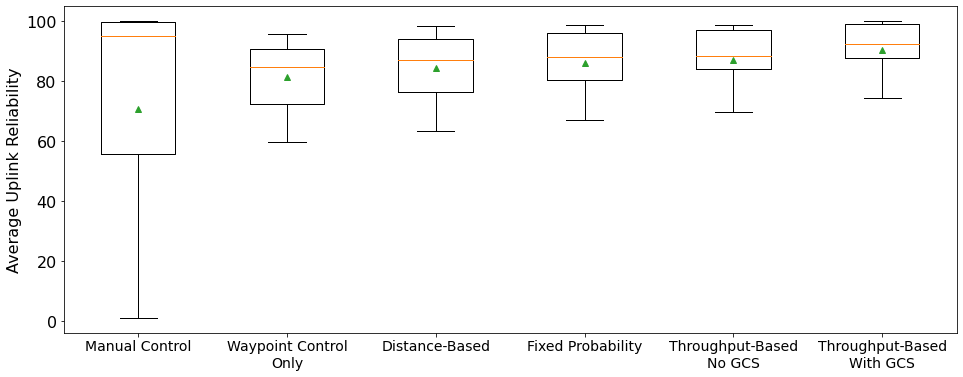

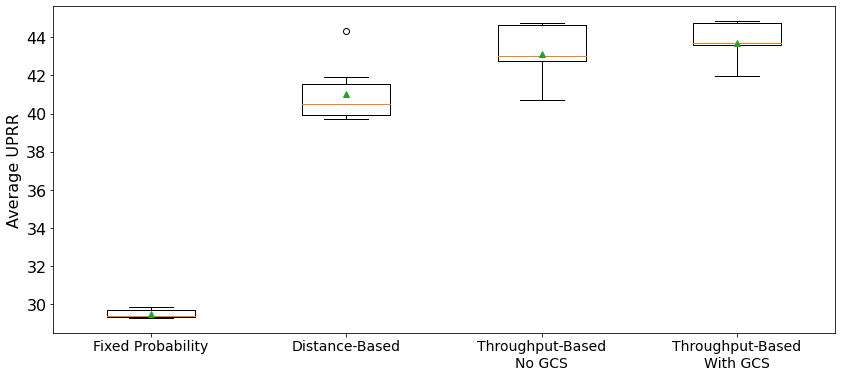

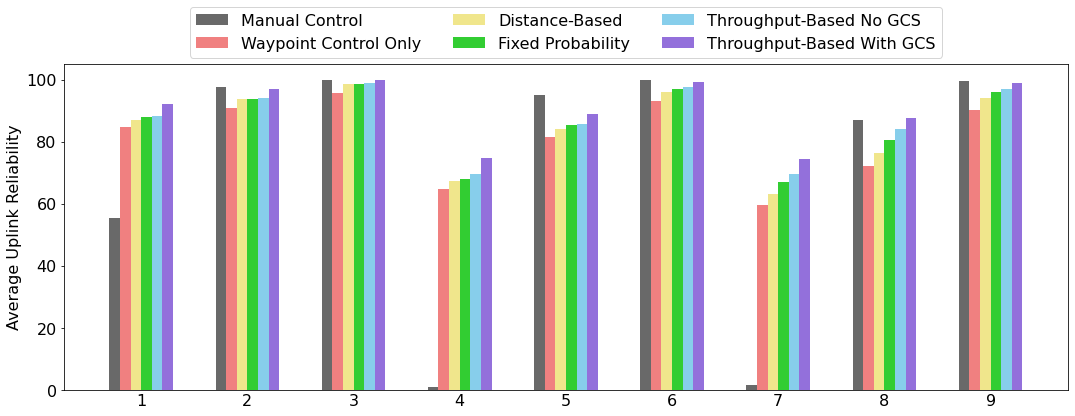

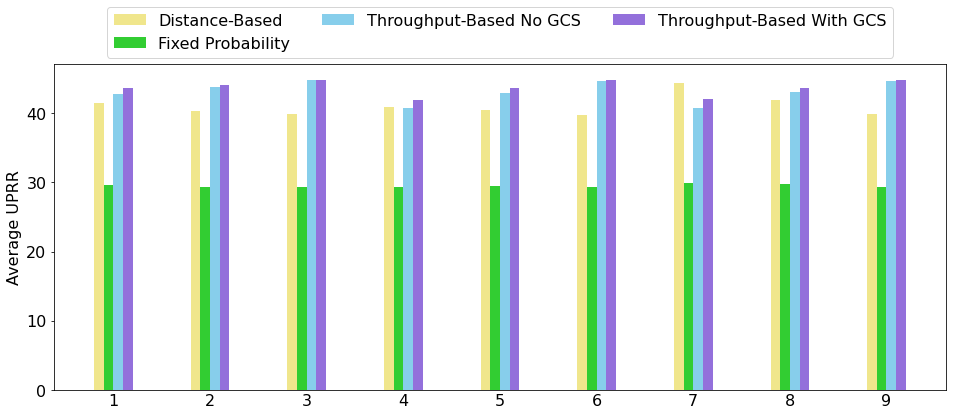

In [5]:
CASE = "default"
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_UAV_Interference/{}_processed"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Waypoint_Only_Broadcast_UAV_Interference/{}_processed"
FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/fixed_prob_{}_processed"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/dvcast_{}_processed"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/throughput_based_{}_processed"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/throughput_based_with_GCS_{}_processed"

manual_df = get_broadcast_results_uav_int(MANUAL_PATH.format(CASE), "Simulation_Results.csv")
waypoint_df = get_broadcast_results_uav_int(WAYPOINT_PATH.format(CASE))
fp_df = get_broadcast_results_uav_int(FP_PATH.format(CASE))
dv_df = get_broadcast_results_uav_int(DV_PATH.format(CASE))
th_df = get_broadcast_results_uav_int(TH_PATH.format(CASE))
th_gcs_df = get_broadcast_results_uav_int(TH_GCS_PATH.format(CASE))

# Plot box plot for Avg DL Reliability
avg_dl_rel_list = [manual_df["avg_dl_rel"].values*100, waypoint_df["avg_dl_rel"].values*100, dv_df["avg_dl_rel"].values*100, fp_df["avg_dl_rel"].values*100, th_df["avg_dl_rel"].values*100, th_gcs_df["avg_dl_rel"].values*100]
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_rel_list, showmeans=True, labels=["Manual Control", "Waypoint Control\nOnly", "Distance-Based", "Fixed Probability", "Throughput-Based\nNo GCS", "Throughput-Based\nWith GCS"])
plt.ylabel("Average Uplink Reliability")
plt.xticks(fontsize=14)

# Plot box plot for Avg DL UPRR
avg_dl_uprr_list = [fp_df["avg_uprr"].values*100, dv_df["avg_uprr"].values*100, th_df["avg_uprr"].values*100, th_gcs_df["avg_uprr"].values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_uprr_list, showmeans=True, labels=["Fixed Probability", "Distance-Based", "Throughput-Based\nNo GCS", "Throughput-Based\nWith GCS"])
plt.ylabel("Average UPRR")
plt.xticks(fontsize=14)

# Plot bar chart for Avg DL Reliability
ind = np.arange(9, dtype=float)  
width = 0.1
fig = plt.figure(figsize=(18, 6))
plt.rcParams.update({'font.size': 16})
bar_manual = plt.bar(ind, manual_df["avg_dl_rel"].values*100, width, color = 'dimgrey')
bar_waypoint = plt.bar(ind + width, waypoint_df["avg_dl_rel"].values*100, width, color = 'lightcoral')
bar_dv = plt.bar(ind + width * 2, dv_df["avg_dl_rel"].values*100, width, color = 'khaki')
bar_fp = plt.bar(ind + width * 3, fp_df["avg_dl_rel"].values*100, width, color = 'limegreen')
bar_th = plt.bar(ind + width * 4, th_df["avg_dl_rel"].values*100, width, color = 'skyblue')
bar_th_gcs = plt.bar(ind + width * 5, th_gcs_df["avg_dl_rel"].values*100, width, color = 'mediumpurple') 
plt.ylabel("Average Uplink Reliability")
plt.xticks(ind+width*2.5, ['1','2','3','4','5','6','7','8','9'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_manual, bar_waypoint, bar_dv, bar_fp, bar_th, bar_th_gcs), ("Manual Control", "Waypoint Control Only", "Distance-Based", "Fixed Probability", "Throughput-Based No GCS", "Throughput-Based With GCS"), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# Plot bar chart for Avg DL Reliability
ind = np.arange(9, dtype=float)  
width = 0.1
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
bar_dv = plt.bar(ind + width, dv_df["avg_uprr"].values*100, width, color = 'khaki')
bar_fp = plt.bar(ind + width * 2, fp_df["avg_uprr"].values*100, width, color = 'limegreen')
bar_th = plt.bar(ind + width * 3, th_df["avg_uprr"].values*100, width, color = 'skyblue')
bar_th_gcs = plt.bar(ind + width * 4, th_gcs_df["avg_uprr"].values*100, width, color = 'mediumpurple') 
plt.ylabel("Average UPRR")
plt.xticks(ind+width*2.5, ['1','2','3','4','5','6','7','8','9'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_dv, bar_fp, bar_th, bar_th_gcs), ("Distance-Based", "Fixed Probability", "Throughput-Based No GCS", "Throughput-Based With GCS"), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

## Plot Results MANET Interference

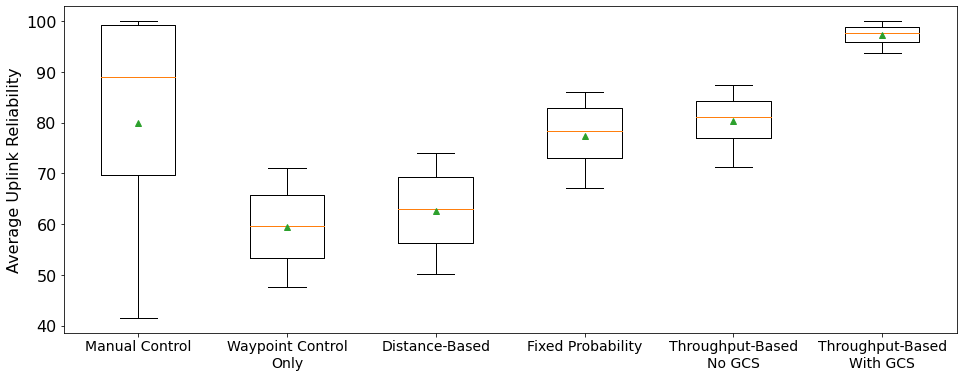

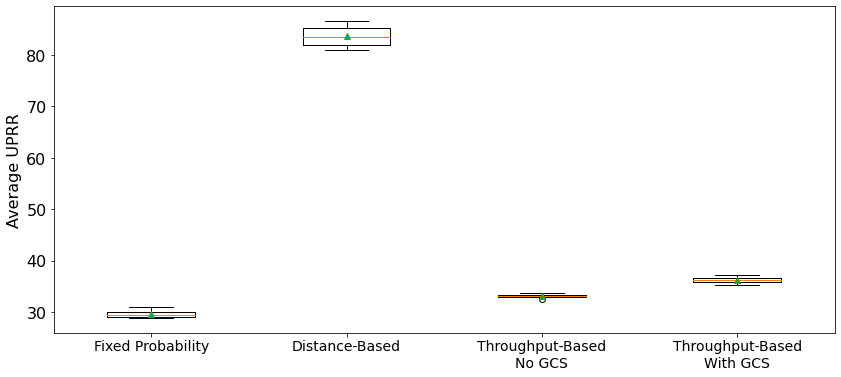

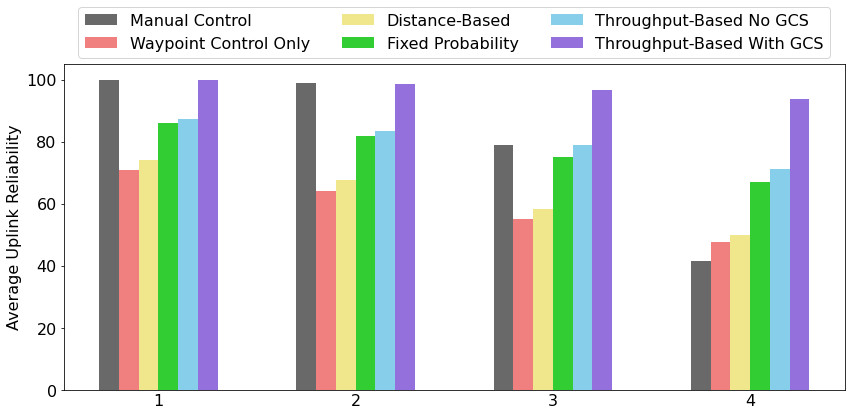

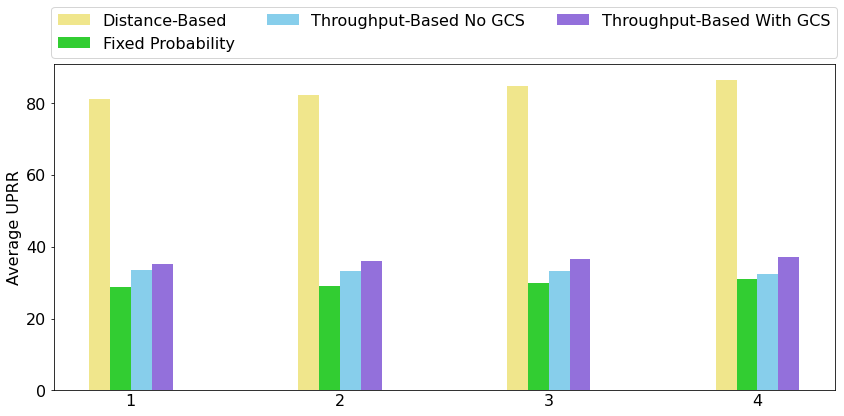

In [4]:
CASE = "case2"
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_MANET_Interference/{}_processed"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Waypoint_Only_Broadcast_MANET_Interference/{}_processed"
FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/fixed_prob_{}_processed"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/dvcast_{}_processed"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/throughput_based_{}_processed"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/throughput_based_with_GCS_{}_processed"

manual_df = get_broadcast_results_manet_int(MANUAL_PATH.format(CASE), "Simulation_Results.csv")
waypoint_df = get_broadcast_results_manet_int(WAYPOINT_PATH.format(CASE))
fp_df = get_broadcast_results_manet_int(FP_PATH.format(CASE))
dv_df = get_broadcast_results_manet_int(DV_PATH.format(CASE))
th_df = get_broadcast_results_manet_int(TH_PATH.format(CASE))
th_gcs_df = get_broadcast_results_manet_int(TH_GCS_PATH.format(CASE))

# Plot box plot for Avg DL Reliability
avg_dl_rel_list = [manual_df["avg_dl_rel"].values*100, waypoint_df["avg_dl_rel"].values*100, dv_df["avg_dl_rel"].values*100, fp_df["avg_dl_rel"].values*100, th_df["avg_dl_rel"].values*100, th_gcs_df["avg_dl_rel"].values*100]
fig = plt.figure(figsize=(16, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_rel_list, showmeans=True, labels=["Manual Control", "Waypoint Control\nOnly", "Distance-Based", "Fixed Probability", "Throughput-Based\nNo GCS", "Throughput-Based\nWith GCS"])
plt.ylabel("Average Uplink Reliability")
plt.xticks(fontsize=14)

# Plot box plot for Avg DL UPRR
avg_dl_uprr_list = [fp_df["avg_uprr"].values*100, dv_df["avg_uprr"].values*100, th_df["avg_uprr"].values*100, th_gcs_df["avg_uprr"].values*100]
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
plt.boxplot(avg_dl_uprr_list, showmeans=True, labels=["Fixed Probability", "Distance-Based", "Throughput-Based\nNo GCS", "Throughput-Based\nWith GCS"])
plt.ylabel("Average UPRR")
plt.xticks(fontsize=14)

# Plot bar chart for Avg DL Reliability
ind = np.arange(4, dtype=float)  
width = 0.1
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
bar_manual = plt.bar(ind, manual_df["avg_dl_rel"].values*100, width, color = 'dimgrey')
bar_waypoint = plt.bar(ind + width, waypoint_df["avg_dl_rel"].values*100, width, color = 'lightcoral')
bar_dv = plt.bar(ind + width * 2, dv_df["avg_dl_rel"].values*100, width, color = 'khaki')
bar_fp = plt.bar(ind + width * 3, fp_df["avg_dl_rel"].values*100, width, color = 'limegreen')
bar_th = plt.bar(ind + width * 4, th_df["avg_dl_rel"].values*100, width, color = 'skyblue')
bar_th_gcs = plt.bar(ind + width * 5, th_gcs_df["avg_dl_rel"].values*100, width, color = 'mediumpurple') 
plt.ylabel("Average Uplink Reliability")
plt.xticks(ind+width*2.5, ['1','2','3','4'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_manual, bar_waypoint, bar_dv, bar_fp, bar_th, bar_th_gcs), ("Manual Control", "Waypoint Control Only", "Distance-Based", "Fixed Probability", "Throughput-Based No GCS", "Throughput-Based With GCS"), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

# Plot bar chart for Avg DL Reliability
ind = np.arange(4, dtype=float)  
width = 0.1
fig = plt.figure(figsize=(14, 6))
plt.rcParams.update({'font.size': 16})
bar_dv = plt.bar(ind + width, dv_df["avg_uprr"].values*100, width, color = 'khaki')
bar_fp = plt.bar(ind + width * 2, fp_df["avg_uprr"].values*100, width, color = 'limegreen')
bar_th = plt.bar(ind + width * 3, th_df["avg_uprr"].values*100, width, color = 'skyblue')
bar_th_gcs = plt.bar(ind + width * 4, th_gcs_df["avg_uprr"].values*100, width, color = 'mediumpurple') 
plt.ylabel("Average UPRR")
plt.xticks(ind+width*2.5, ['1','2','3','4'])
plt.tick_params(axis='x', which='both',length=0)
plt.legend( (bar_dv, bar_fp, bar_th, bar_th_gcs), ("Distance-Based", "Fixed Probability", "Throughput-Based No GCS", "Throughput-Based With GCS"), bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower center", borderaxespad=0, ncol=3) 

### Get Averages UAV Int

In [16]:
CASES = ["default", "case1", "case2", "case3", "case4", "case5", "case6", "case7", "case8", "case9", "case10"]
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_UAV_Interference/{}_processed"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Waypoint_Only_Broadcast_UAV_Interference/{}_processed"
FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/fixed_prob_{}_processed"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/dvcast_{}_processed"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/throughput_based_{}_processed"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_UAV_Interference/throughput_based_with_GCS_{}_processed"

avg_dl_rel_list = []
avg_dl_uprr_list = []
for case in CASES:
    manual_df = get_broadcast_results_uav_int(MANUAL_PATH.format(case), "Simulation_Results.csv")
    waypoint_df = get_broadcast_results_uav_int(WAYPOINT_PATH.format(case))
    fp_df = get_broadcast_results_uav_int(FP_PATH.format(case))
    dv_df = get_broadcast_results_uav_int(DV_PATH.format(case))
    th_df = get_broadcast_results_uav_int(TH_PATH.format(case))
    th_gcs_df = get_broadcast_results_uav_int(TH_GCS_PATH.format(case))
    avg_dl_rel_list.append({"Manual": manual_df["avg_dl_rel"].mean()*100, "Waypoint": waypoint_df["avg_dl_rel"].mean()*100, "FP": fp_df["avg_dl_rel"].mean()*100, 
                            "DV": dv_df["avg_dl_rel"].mean()*100, "TH": th_df["avg_dl_rel"].mean()*100, "TH_GCS": th_gcs_df["avg_dl_rel"].mean()*100})
    avg_dl_uprr_list.append({"FP": fp_df["avg_uprr"].mean()*100, "DV": dv_df["avg_uprr"].mean()*100, "TH": th_df["avg_uprr"].mean()*100, "TH_GCS": th_gcs_df["avg_uprr"].mean()*100})

avg_dl_rel_df = pd.DataFrame(avg_dl_rel_list)
avg_dl_rel_df.to_csv("avg_dl_rel_uav.csv")
avg_dl_uprr_df = pd.DataFrame(avg_dl_uprr_list)
avg_dl_uprr_df.to_csv("avg_dl_uprr_uav.csv")

### Get Averages MANET Int

In [18]:
CASES = ["default", "case1", "case2", "case3", "case4", "case5", "case6", "case7", "case8"]
MANUAL_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Manual_Control_MANET_Interference/{}_processed"
WAYPOINT_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Waypoint_Only_Broadcast_MANET_Interference/{}_processed"
FP_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/fixed_prob_{}_processed"
DV_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/dvcast_{}_processed"
TH_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/throughput_based_{}_processed"
TH_GCS_PATH = "/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Obj3_Retransmission_Datasets/DJISpark_Retransmission_Protocols_MANET_Interference/throughput_based_with_GCS_{}_processed"

avg_dl_rel_list = []
avg_dl_uprr_list = []
for case in CASES:
    manual_df = get_broadcast_results_manet_int(MANUAL_PATH.format(case), "Simulation_Results.csv")
    waypoint_df = get_broadcast_results_manet_int(WAYPOINT_PATH.format(case))
    fp_df = get_broadcast_results_manet_int(FP_PATH.format(case))
    dv_df = get_broadcast_results_manet_int(DV_PATH.format(case))
    th_df = get_broadcast_results_manet_int(TH_PATH.format(case))
    th_gcs_df = get_broadcast_results_manet_int(TH_GCS_PATH.format(case))
    avg_dl_rel_list.append({"Manual": manual_df["avg_dl_rel"].mean()*100, "Waypoint": waypoint_df["avg_dl_rel"].mean()*100, "FP": fp_df["avg_dl_rel"].mean()*100, 
                            "DV": dv_df["avg_dl_rel"].mean()*100, "TH": th_df["avg_dl_rel"].mean()*100, "TH_GCS": th_gcs_df["avg_dl_rel"].mean()*100})
    avg_dl_uprr_list.append({"FP": fp_df["avg_uprr"].mean()*100, "DV": dv_df["avg_uprr"].mean()*100, "TH": th_df["avg_uprr"].mean()*100, "TH_GCS": th_gcs_df["avg_uprr"].mean()*100})

avg_dl_rel_df = pd.DataFrame(avg_dl_rel_list)
avg_dl_rel_df.to_csv("avg_dl_rel_manet.csv")
avg_dl_uprr_df = pd.DataFrame(avg_dl_uprr_list)
avg_dl_uprr_df.to_csv("avg_dl_uprr_manet.csv")